In [2]:
# --- Environment & determinism ---
import os, time, math, gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from contextlib import contextmanager

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(1337)
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')

def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

@contextmanager
def timed(msg):
    cuda_sync()
    t0 = time.perf_counter()
    yield
    cuda_sync()
    dt = time.perf_counter() - t0
    print(f"{msg}: {dt:.3f}s")

def peak_mem(reset=True):
    if torch.cuda.is_available():
        m = torch.cuda.max_memory_allocated() / (1024**2)
        if reset:
            torch.cuda.reset_peak_memory_stats()
        return m
    return 0.0

# --- Tiny Shakespeare (char-level) ---
import requests, io
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(URL, timeout=10).text
vocab = sorted(list(set(text)))
stoi = {c:i for i,c in enumerate(vocab)}
itos = {i:c for i,c in enumerate(vocab)}
encode = lambda s: torch.tensor([stoi[c] for c in s], dtype=torch.long)
decode = lambda t: ''.join([itos[i] for i in t.tolist()])

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
split = int(0.9 * len(data))
train, val = data[:split], data[split:]

def get_batch(data, batch_size, block_size):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [3]:
def apply_rope(x, cos, sin):
    """
    x:   [B, T, H, D]  (H=n_heads, D=head_dim)
    cos: [T, D]
    sin: [T, D]
    returns: [B, T, H, D]
    """
    B, T, H, D = x.shape
    assert D % 2 == 0, "RoPE requires even head_dim"

    # Broadcast cos/sin over batch and heads
    cos = cos[None, :, None, :]  # [1, T, 1, D]
    sin = sin[None, :, None, :]  # [1, T, 1, D]

    # Split last dim into pairs
    x1, x2 = x[..., ::2], x[..., 1::2]
    c, s   = cos[..., ::2], sin[..., ::2]

    xr1 = x1 * c - x2 * s
    xr2 = x1 * s + x2 * c

    out = torch.empty_like(x)
    out[..., ::2] = xr1
    out[..., 1::2] = xr2
    return out

In [4]:
# 🌀 RoPE helpers (define this BEFORE defining/using GPTMini)
import torch

def apply_rope(x, cos, sin):
    """
    x:   [B, T, H, D]  (D must be even)
    cos: [T, D]
    sin: [T, D]
    returns: [B, T, H, D]
    """
    B, T, H, D = x.shape
    assert D % 2 == 0, "RoPE requires even head_dim"

    # broadcast cos/sin over batch and heads
    cos = cos[None, :, None, :]  # [1, T, 1, D]
    sin = sin[None, :, None, :]  # [1, T, 1, D]

    x1, x2 = x[..., ::2], x[..., 1::2]
    c, s   = cos[..., ::2], sin[..., ::2]

    xr1 = x1 * c - x2 * s
    xr2 = x1 * s + x2 * c

    out = torch.empty_like(x)
    out[..., ::2] = xr1
    out[..., 1::2] = xr2
    return out

def rope_cache(T, head_dim, base=10000.0, device='cuda'):
    """Build RoPE cos/sin tables for a length-T block."""
    pos = torch.arange(T, device=device, dtype=torch.float32)        # [T]
    idx = torch.arange(head_dim, device=device, dtype=torch.float32) # [D]
    inv = 1.0 / (base ** (idx / head_dim))
    freqs = torch.einsum('t,d->td', pos, inv)  # [T, D]
    return torch.cos(freqs), torch.sin(freqs)

def rope_single(pos, head_dim, base=10000.0, device='cuda'):
    """
    Single-position RoPE cos/sin for streaming. Returns shape [1, D] each,
    which we pass to apply_rope (which expects [T, D]; T=1 is fine).
    """
    idx = torch.arange(head_dim, device=device, dtype=torch.float32) # [D]
    inv = 1.0 / (base ** (idx / head_dim))
    freqs = pos * inv  # [D]
    cos = torch.cos(freqs).unsqueeze(0)  # [1, D]
    sin = torch.sin(freqs).unsqueeze(0)  # [1, D]
    return cos, sin

In [5]:
def rope_cache(T, head_dim, base=10000.0, device='cuda'):
    pos = torch.arange(T, device=device, dtype=torch.float32)          # [T]
    idx = torch.arange(head_dim, device=device, dtype=torch.float32)   # [D]
    inv_freq = 1.0 / (base ** (idx / head_dim))
    freqs = torch.einsum('t,d->td', pos, inv_freq)                     # [T, D]
    return torch.cos(freqs), torch.sin(freqs)

In [6]:
with torch.no_grad():
    B,T,H,D = 2, 16, 6, 64
    x = torch.randn(B,T,H,D, device=device)
    from math import pi
    # use your rope_cache
    cos, sin = rope_cache(T, D, device=device)
    y = apply_rope(x, cos, sin)
    assert y.shape == x.shape

In [7]:
# --- Cache policy interface ---
class CachePolicy:
    def reset(self, B, D, device):
        raise NotImplementedError
    def append(self, k, v):  # k,v: [B, 1, D]
        raise NotImplementedError
    def memory(self):        # returns K_all, V_all as [B, Tm, D]
        raise NotImplementedError

# --- Full cache (standard KV) ---
class FullCache(CachePolicy):
    def __init__(self, max_T=65536):
        self.max_T = max_T
        self.K = None
        self.V = None
    def reset(self, B, D, device):
        self.K = []
        self.V = []
    def append(self, k, v):
        self.K.append(k)  # each [B,1,D]
        self.V.append(v)
    def memory(self):
        if not self.K:
            return None, None
        K_all = torch.cat(self.K, dim=1)  # [B, Tm, D]
        V_all = torch.cat(self.V, dim=1)
        return K_all, V_all

# --- Sliding window ---
class SlidingWindow(CachePolicy):
    def __init__(self, L=1024):
        self.L = L
        self.K = []
        self.V = []
    def reset(self, B, D, device):
        self.K, self.V = [], []
    def append(self, k, v):
        self.K.append(k); self.V.append(v)
        if len(self.K) > self.L:
            self.K.pop(0); self.V.pop(0)
    def memory(self):
        if not self.K: return None, None
        return torch.cat(self.K, 1), torch.cat(self.V, 1)

# --- Hierarchical (your idea) ---
from collections import deque
class HiKV(CachePolicy):
    def __init__(self, W0=64, W1=16, W2=4, compress='mean'):
        self.W0, self.W1, self.W2 = W0, W1, W2
        self.compress = compress
        self.L0K = deque(maxlen=W0); self.L0V = deque(maxlen=W0)
        self.L1K = deque(maxlen=W1); self.L1V = deque(maxlen=W1)
        self.L2K = deque(maxlen=W2); self.L2V = deque(maxlen=W2)
    def reset(self, B, D, device):
        self.L0K.clear(); self.L0V.clear()
        self.L1K.clear(); self.L1V.clear()
        self.L2K.clear(); self.L2V.clear()
        self._B, self._D, self._dev = B, D, device
    def _pool(self, Klist, Vlist):
        # mean pooling; plug EMA/attn here for ablations
        K = torch.cat(Klist, dim=1)  # [B,T,D]
        V = torch.cat(Vlist, dim=1)
        return K.mean(dim=1, keepdim=True), V.mean(dim=1, keepdim=True)  # [B,1,D]
    def _flush_L0_to_L1(self):
        if len(self.L0K) == 0: return
        K = [x for x in self.L0K]; V = [x for x in self.L0V]
        Kp, Vp = self._pool(K, V)
        self.L1K.append(Kp); self.L1V.append(Vp)
        self.L0K.clear(); self.L0V.clear()
    def _flush_L1_to_L2(self):
        if len(self.L1K) == 0: return
        K = [x for x in self.L1K]; V = [x for x in self.L1V]
        Kp, Vp = self._pool(K, V)
        self.L2K.append(Kp); self.L2V.append(Vp)
        self.L1K.clear(); self.L1V.clear()
    def append(self, k, v):  # k,v: [B,1,D]
        self.L0K.append(k); self.L0V.append(v)
        if len(self.L0K) == self.W0:
            self._flush_L0_to_L1()
        if len(self.L1K) == self.W1:
            self._flush_L1_to_L2()
    def memory(self):
        stacks = []
        if len(self.L2K): stacks.append((list(self.L2K), list(self.L2V)))
        if len(self.L1K): stacks.append((list(self.L1K), list(self.L1V)))
        if len(self.L0K): stacks.append((list(self.L0K), list(self.L0V)))
        if not stacks: return None, None
        K_all = torch.cat([torch.cat(klist, 1) for klist, _ in stacks], dim=1)
        V_all = torch.cat([torch.cat(vlist, 1) for _, vlist in stacks], dim=1)
        return K_all, V_all

# --- Optional: EMA compressive cache for ablation ---
class EMACache(CachePolicy):
    def __init__(self, W=128, alpha=0.9):
        self.W, self.alpha = W, alpha
        self.bufK = None; self.bufV = None; self.len = 0
    def reset(self, B, D, device):
        self.bufK = torch.zeros(B, self.W, D, device=device)
        self.bufV = torch.zeros(B, self.W, D, device=device)
        self.len = 0
    def append(self, k, v):
        if self.len < self.W:
            self.bufK[:, self.len:self.len+1, :] = k
            self.bufV[:, self.len:self.len+1, :] = v
            self.len += 1
        else:
            # EMA on the last slot for cheap compression
            self.bufK[:, -1, :] = self.alpha * self.bufK[:, -1, :] + (1 - self.alpha) * k.squeeze(1)
            self.bufV[:, -1, :] = self.alpha * self.bufV[:, -1, :] + (1 - self.alpha) * v.squeeze(1)
    def memory(self):
        if self.len == 0: return None, None
        return self.bufK[:, :self.len, :], self.bufV[:, :self.len, :]

In [8]:
'''
class MultiHeadSelfAttn(nn.Module):

    def __init__(self, embed_size, n_heads, cache_policy=None, dropout=0.0):
        super().__init__()
        assert embed_size % n_heads == 0
        self.embed_size = embed_size
        self.n_heads = n_heads
        self.head_dim = embed_size // n_heads
        self.Wq = nn.Linear(embed_size, embed_size, bias=False)
        self.Wk = nn.Linear(embed_size, embed_size, bias=False)
        self.Wv = nn.Linear(embed_size, embed_size, bias=False)
        self.proj = nn.Linear(embed_size, embed_size, bias=False)
        self.drop = nn.Dropout(dropout)
        self.cache_policy = cache_policy  # None during training; set at inference

    def reset_cache(self, B, device):
        if self.cache_policy is not None:
            self.cache_policy.reset(B, self.head_dim, device)

    def forward(self, x, use_cache=False, cos=None, sin=None):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # Project
        q = self.Wq(x).view(B, T, H, D)
        k = self.Wk(x).view(B, T, H, D)
        v = self.Wv(x).view(B, T, H, D)

        # Apply RoPE to q and k (values are not rotated)
        if cos is not None and sin is not None:
            q = apply_rope(q, cos[:T, :], sin[:T, :])
            k = apply_rope(k, cos[:T, :], sin[:T, :])

        if not use_cache:
            # Training path: standard causal attention
            qh = q.permute(0, 2, 1, 3)  # [B, H, T, D]
            kh = k.permute(0, 2, 1, 3)  # [B, H, T, D]
            vh = v.permute(0, 2, 1, 3)  # [B, H, T, D]

            att = (qh @ kh.transpose(-1, -2)) / math.sqrt(D)  # [B,H,T,T]
            mask = torch.triu(
                torch.full((T, T), float('-inf'), device=x.device), diagonal=1
            )
            att = att + mask  # broadcasts over [B,H]
            wei = att.softmax(dim=-1)

            out = (wei @ vh)  # [B,H,T,D]
            out = out.transpose(1, 2).contiguous().view(B, T, C)  # [B,T,C]
            return self.drop(self.proj(out))

        else:
            # Inference path (streaming): T must be 1
            assert T == 1, "use_cache=True expects T=1 for streaming decode"

            # Merge heads for cache (simple and consistent across policies)
            q_merge = q.permute(0,2,1,3).contiguous().view(B, 1, C)  # [B,1,C]
            k_merge = k.permute(0,2,1,3).contiguous().view(B, 1, C)  # [B,1,C]
            v_merge = v.permute(0,2,1,3).contiguous().view(B, 1, C)  # [B,1,C]

            self.cache_policy.append(k_merge, v_merge)
            K_all, V_all = self.cache_policy.memory()  # [B,Tm,C], [B,Tm,C] or (None, None)

            if K_all is None:
                out = torch.zeros(B, 1, C, device=x.device, dtype=x.dtype)
            else:
                wei = (q_merge @ K_all.transpose(-1, -2)) / math.sqrt(D)  # scale by per-head dim
                wei = wei.softmax(dim=-1)
                out = wei @ V_all  # [B,1,C]

            return self.drop(self.proj(out))

class MultiHeadSelfAttn(nn.Module):
    def __init__(self, embed_size, n_heads, dropout=0.0):
        super().__init__()
        assert embed_size % n_heads == 0
        self.C = embed_size
        self.H = n_heads
        self.dh = embed_size // n_heads
        self.Wq = nn.Linear(self.C, self.C, bias=False)
        self.Wk = nn.Linear(self.C, self.C, bias=False)
        self.Wv = nn.Linear(self.C, self.C, bias=False)
        # Your model print shows it's named 'proj' instead of 'Wo'
        self.proj = nn.Linear(self.C, self.C, bias=False)
        self.drop = nn.Dropout(0.1)
        self.cache_policy = None

    def reset_cache(self, B, device):
        if self.cache_policy is not None:
            # ✅ merged-head cache width is C
            self.cache_policy.reset(B, self.C, device)

    def forward(self, x, use_cache=False, cos=None, sin=None):
        B, T, C = x.shape
        H, dh = self.H, self.dh
        q = self.Wq(x).view(B, T, H, dh)
        k = self.Wk(x).view(B, T, H, dh)
        v = self.Wv(x).view(B, T, H, dh)
        if cos is not None and sin is not None:
            q = apply_rope(q, cos, sin)
            k = apply_rope(k, cos, sin)

        if not use_cache:
            qh = q.permute(0,2,1,3)
            kh = k.permute(0,2,1,3)
            vh = v.permute(0,2,1,3)
            scores = (qh @ kh.transpose(-1,-2)) / math.sqrt(dh)
            mask = torch.triu(torch.full((T,T), float('-inf'), device=x.device), diagonal=1)
            scores = scores + mask
            wei = scores.softmax(dim=-1)
            out = (wei @ vh).transpose(1,2).contiguous().view(B, T, C)
            return self.drop(self.proj(out))
        else:
            assert T == 1, "Streaming path expects T=1"
            q_ = q.permute(0,2,1,3).contiguous().view(B, 1, C)
            k_ = k.permute(0,2,1,3).contiguous().view(B, 1, C)
            v_ = v.permute(0,2,1,3).contiguous().view(B, 1, C)
            self.cache_policy.append(k_, v_)
            K_all, V_all = self.cache_policy.memory()
            if K_all is None:
                out = torch.zeros(B, 1, C, device=x.device, dtype=x.dtype)
            else:
                wei = (q_ @ K_all.transpose(-1,-2)) / math.sqrt(dh)
                wei = wei.softmax(dim=-1)
                out = wei @ V_all
            return self.drop(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, embed_size, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_size, 4*embed_size),
            nn.GELU(),
            nn.Linear(4*embed_size, embed_size),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, embed_size, n_heads, dropout=0.0, cache_policy=None):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)
        self.attn = MultiHeadSelfAttn(embed_size, n_heads, cache_policy, dropout=dropout)
        self.ff = FeedForward(embed_size, dropout=dropout)
    def reset_cache(self, B, device):
        self.attn.reset_cache(B, device)
    def forward(self, x, use_cache=False, cos=None, sin=None):
        x = x + self.attn(self.ln1(x), use_cache=use_cache, cos=cos, sin=sin)
        x = x + self.ff(self.ln2(x))
        return x

class GPTMini(nn.Module):
    def __init__(self, vocab_size, embed_size=512, n_layers=6, n_heads=8, block_size=512, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.block_size = block_size
        self.tok = nn.Embedding(vocab_size, embed_size)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(embed_size, n_heads, dropout=dropout, cache_policy=None)
                                     for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(embed_size)
        self.head = nn.Linear(embed_size, vocab_size, bias=False)

    def set_cache_policy(self, policy):  # set for inference
        for b in self.blocks:
            b.attn.cache_policy = policy

    def reset_cache(self, B=1, device='cuda'):
        for b in self.blocks:
            b.reset_cache(B, device)

    def forward(self, idx, targets=None, use_cache=False):
        B, T = idx.shape
        assert T <= self.block_size or use_cache, "T exceeds block_size"
        x = self.tok(idx)  # [B,T,C]
        x = self.drop(x)
        cos = sin = None
        if not use_cache:
            cos, sin = rope_cache(T, self.blocks[0].attn.head_dim, device=x.device)
        else:
            # streaming step; we build cos/sin with T=1 and cumulative position is handled
            cos, sin = rope_cache(1, self.blocks[0].attn.head_dim, device=x.device)

        for b in self.blocks:
            x = b(x, use_cache=use_cache, cos=cos, sin=sin)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None and not use_cache:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss
'''
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- assumes apply_rope, rope_cache, rope_single already defined ---

class MultiHeadSelfAttn(nn.Module):
    def __init__(self, embed_size, n_heads, dropout=0.0):
        super().__init__()
        assert embed_size % n_heads == 0
        self.C = embed_size
        self.H = n_heads
        self.dh = embed_size // n_heads

        self.Wq = nn.Linear(self.C, self.C, bias=False)
        self.Wk = nn.Linear(self.C, self.C, bias=False)
        self.Wv = nn.Linear(self.C, self.C, bias=False)
        # Your printed model shows 'proj' (not 'Wo'), so keep this name:
        self.proj = nn.Linear(self.C, self.C, bias=False)
        self.drop = nn.Dropout(dropout)

        # set at inference via model.set_cache_policy(...)
        self.cache_policy = None

    def reset_cache(self, B, device):
        if self.cache_policy is not None:
            # IMPORTANT: merged-head caching → width is C (embed_size), not dh
            self.cache_policy.reset(B, self.C, device)

    def forward(self, x, use_cache=False, cos=None, sin=None):
        B, T, C = x.shape
        H, dh = self.H, self.dh

        q = self.Wq(x).view(B, T, H, dh)
        k = self.Wk(x).view(B, T, H, dh)
        v = self.Wv(x).view(B, T, H, dh)

        if cos is not None and sin is not None:
            q = apply_rope(q, cos, sin)
            k = apply_rope(k, cos, sin)

        if not use_cache:
            # training path: standard causal attention
            qh = q.permute(0, 2, 1, 3)  # [B,H,T,dh]
            kh = k.permute(0, 2, 1, 3)
            vh = v.permute(0, 2, 1, 3)

            scores = (qh @ kh.transpose(-1, -2)) / math.sqrt(dh)  # [B,H,T,T]
            mask = torch.triu(torch.full((T, T), float('-inf'), device=x.device), diagonal=1)
            scores = scores + mask
            wei = scores.softmax(dim=-1)
            out = (wei @ vh).transpose(1, 2).contiguous().view(B, T, C)  # [B,T,C]
            return self.drop(self.proj(out))
        else:
            # streaming path: T must be 1; merged-head caching
            assert T == 1, "use_cache=True expects T=1"
            q_ = q.permute(0, 2, 1, 3).contiguous().view(B, 1, C)  # [B,1,C]
            k_ = k.permute(0, 2, 1, 3).contiguous().view(B, 1, C)
            v_ = v.permute(0, 2, 1, 3).contiguous().view(B, 1, C)

            self.cache_policy.append(k_, v_)
            K_all, V_all = self.cache_policy.memory()  # [B,Tm,C] each (or None)

            if K_all is None:
                out = torch.zeros(B, 1, C, device=x.device, dtype=x.dtype)
            else:
                wei = (q_ @ K_all.transpose(-1, -2)) / math.sqrt(dh)  # scale by dh
                wei = wei.softmax(dim=-1)
                out = wei @ V_all  # [B,1,C]

            return self.drop(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, embed_size, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_size, 4*embed_size),
            nn.GELU(),
            nn.Linear(4*embed_size, embed_size),
            nn.Dropout(dropout)
        )
    def forward(self, x): return self.net(x)


class Block(nn.Module):
    def __init__(self, embed_size, n_heads, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)
        # ✅ do NOT pass cache_policy here
        self.attn = MultiHeadSelfAttn(embed_size, n_heads, dropout=dropout)
        self.ff = FeedForward(embed_size, dropout=dropout)
    def reset_cache(self, B, device): self.attn.reset_cache(B, device)
    def forward(self, x, use_cache=False, cos=None, sin=None):
        x = x + self.attn(self.ln1(x), use_cache=use_cache, cos=cos, sin=sin)
        x = x + self.ff(self.ln2(x))
        return x


class GPTMini(nn.Module):
    def __init__(self, vocab_size, embed_size=384, n_layers=6, n_heads=6, block_size=256, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.block_size = block_size

        self.tok = nn.Embedding(vocab_size, embed_size)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(embed_size, n_heads, dropout=dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(embed_size)
        self.head = nn.Linear(embed_size, vocab_size, bias=False)

        # running position for streaming RoPE
        self.stream_pos = 0

    def set_cache_policy(self, policy):
        # set same policy instance on all blocks; or clone if you prefer independent
        for b in self.blocks:
            b.attn.cache_policy = policy

    def reset_cache(self, B=1, device='cuda'):
        self.stream_pos = 0
        for b in self.blocks:
            b.reset_cache(B, device)

    def forward(self, idx, targets=None, use_cache=False):
        B, T = idx.shape
        assert (not use_cache and T <= self.block_size) or use_cache, "T exceeds block_size in training"
        x = self.tok(idx)
        x = self.drop(x)

        if not use_cache:
            cos, sin = rope_cache(T, self.blocks[0].attn.dh, device=x.device)
        else:
            cos, sin = rope_single(self.stream_pos, self.blocks[0].attn.dh, device=x.device)

        for b in self.blocks:
            x = b(x, use_cache=use_cache, cos=cos, sin=sin)

        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None and not use_cache:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))

        if use_cache:
            self.stream_pos += T
        return logits, loss



In [9]:
def train_gpt(model, steps=2000, lr=3e-4, batch_size=64, block_size=256, eval_every=200):
    model.train().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=0.1)
    for step in range(steps):
        xb, yb = get_batch(train, batch_size, block_size)
        logits, loss = model(xb, yb, use_cache=False)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        if (step+1) % eval_every == 0:
            with torch.no_grad():
                model.eval()
                xb, yb = get_batch(val, 256, block_size)
                logits, loss_val = model(xb, yb, use_cache=False)
                print(f"step {step+1}: train_loss={loss.item():.3f} val_loss={loss_val.item():.3f}")
                model.train()
    return model

In [10]:
@torch.no_grad()
def eval_ppl(model, dataset, block_size=256, batch_size=256):
    model.eval()
    losses = []
    for _ in range(50):
        xb, yb = get_batch(dataset, batch_size, block_size)
        logits, loss = model(xb, yb, use_cache=False)
        losses.append(loss.item())
    import numpy as np
    mean_loss = float(np.mean(losses))
    bpc = mean_loss / math.log(2)
    ppl = math.exp(mean_loss)
    print(f"Loss {mean_loss:.3f} | PPL {ppl:.2f} | BPC {bpc:.3f}")
    return dict(loss=mean_loss, ppl=ppl, bpc=bpc)

In [11]:
@torch.no_grad()
def stream_benchmark(model, cache_policy, start_token, steps=4096, temperature=1.0, top_p=0.9):
    model.eval()
    model.set_cache_policy(cache_policy)
    model.reset_cache(B=start_token.shape[0], device=device)
    peak_mem(reset=True)

    idx = start_token.clone().to(device)  # [B,1]
    toks = []
    cuda_sync()
    t0 = time.perf_counter()

    # warmup
    for _ in range(16):
        logits, _ = model(idx, use_cache=True)
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        idx = torch.multinomial(probs, num_samples=1)

    cuda_sync()
    t1 = time.perf_counter()
    # timed run
    for _ in range(steps):
        logits, _ = model(idx, use_cache=True)
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        idx = torch.multinomial(probs, num_samples=1)
        toks.append(idx.item())

    cuda_sync()
    t2 = time.perf_counter()

    gen_time = (t2 - t1)
    toks_sec = steps / gen_time
    mem_mb = peak_mem(reset=True)
    return {"tokens": toks, "tokens_sec": toks_sec, "latency_ms": 1000.0*gen_time/steps, "peak_mem_mb": mem_mb}

In [12]:
import random
@torch.no_grad()
def needle_in_haystack(model, cache_policy, ctx_len=4096, needle_pos=3000, trials=50):
    """
    Generate a random context of length ctx_len with a 'needle' char at needle_pos,
    then ask the model to reproduce it when prompted with a cue token later.
    Metric: % trials where the exact needle is produced on the next step.
    """
    model.eval()
    success = 0
    for _ in range(trials):
        # build synthetic context
        base = torch.randint(low=0, high=model.vocab_size, size=(ctx_len,), device=device)
        needle = base[needle_pos].view(1)
        # stream it
        model.set_cache_policy(cache_policy)
        model.reset_cache(B=1, device=device)
        idx = base[0:1].view(1,1)
        for t in range(1, ctx_len):
            logits, _ = model(idx, use_cache=True)
            # feed next true token (teacher forcing) to move through context
            idx = base[t:t+1].view(1,1)
        # now ask to predict the next token (should reproduce last seen 'needle' if the prompt queries it)
        logits, _ = model(idx, use_cache=True)
        pred = torch.argmax(logits[:, -1, :], dim=-1)
        success += int(pred.item() == base[-1].item())  # naive; adapt with a cueing strategy if needed
    return {"ctx_len": ctx_len, "needle_pos": needle_pos, "retrieval_rate": success / trials}

In [13]:
# 1) Instantiate and train a small model
vocab_size = len(vocab)
model = GPTMini(vocab_size, embed_size=384, n_layers=6, n_heads=6, block_size=256, dropout=0.1).to(device)
#model = train_gpt(model, steps=1500, lr=3e-4, batch_size=64, block_size=256, eval_every=250)

# 2) Quality on val
#val_stats = eval_ppl(model, val, block_size=256)

# 3) Streaming benchmarks across policies
#start_tok = torch.randint(0, vocab_size, (1,1), device=device)

#policies = {
    #"FullCache": FullCache(),
    #"SlidingWindow_512": SlidingWindow(L=512),
    #"HiKV_64_16_4": HiKV(W0=64, W1=16, W2=4)

#}



In [12]:
# Save model weights
torch.save(model.state_dict(), "gptmini_hkv_checkpoint.pth")

In [16]:

results = {}
for name, pol in policies.items():
    print(f"\n=== {name} ===")
    res = stream_benchmark(model, pol, start_tok, steps=4096)
    print(res)
    results[name] = res



=== FullCache ===
{'tokens': [1, 58, 56, 47, 58, 46, 47, 47, 58, 53, 1, 58, 53, 41, 58, 53, 58, 46, 43, 57, 46, 47, 58, 58, 53, 1, 46, 53, 1, 51, 43, 58, 47, 58, 47, 57, 58, 53, 57, 58, 53, 5, 58, 57, 41, 56, 39, 58, 43, 43, 57, 58, 56, 43, 58, 56, 43, 57, 58, 53, 58, 43, 1, 54, 43, 57, 63, 57, 58, 56, 43, 57, 58, 56, 46, 47, 43, 63, 8, 0, 0, 0, 37, 1, 31, 57, 41, 53, 61, 39, 43, 39, 56, 43, 43, 1, 16, 53, 41, 46, 39, 39, 56, 40, 43, 57, 58, 56, 47, 41, 46, 39, 56, 53, 56, 47, 52, 47, 56, 53, 54, 53, 41, 46, 43, 1, 13, 57, 61, 47, 56, 63, 54, 54, 54, 54, 54, 54, 54, 54, 54, 46, 41, 47, 39, 58, 47, 39, 56, 47, 52, 47, 56, 53, 45, 43, 1, 48, 59, 47, 41, 47, 41, 46, 41, 53, 1, 24, 1, 30, 39, 56, 59, 43, 51, 39, 56, 63, 1, 19, 50, 47, 52, 39, 63, 57, 58, 59, 47, 52, 39, 56, 47, 50, 53, 1, 46, 47, 45, 50, 39, 56, 47, 52, 50, 47, 51, 47, 57, 58, 46, 47, 52, 39, 58, 46, 47, 52, 53, 1, 32, 53, 59, 47, 52, 53, 10, 0, 0, 15, 53, 1, 32, 46, 47, 45, 43, 1, 20, 17, 52, 53, 41, 43, 51, 47, 57, 59, 

In [14]:
#@title 🔧 Environment & helpers (T4 friendly)
import os, time, math, gc, random, warnings
from contextlib import contextmanager
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cpu', "Please switch Colab runtime to GPU (T4). Runtime → Change runtime type → GPU."

# Determinism-ish + perf
torch.manual_seed(1337)
random.seed(1337)
np.random.seed(1337)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def reset_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def peak_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024**2)
    return 0.0

In [15]:
# ⚡ Streaming benchmark with AMP (bf16) on T4
def top_p_filtering(logits, top_p=0.9, temperature=1.0):
    """logits: [B, V] → filtered logits [B, V] with -inf outside top-p.
       Uses .clone() to avoid overlapping assignment."""
    # sort by logit descending
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits / max(1e-6, temperature), dim=-1)
    cumprobs = torch.cumsum(sorted_probs, dim=-1)

    # mask tokens beyond nucleus threshold
    remove = cumprobs > top_p
    # shift mask right by one so we always keep at least the first token above the threshold
    remove[..., 1:] = remove[..., :-1].clone()  # <-- critical fix
    remove[..., 0] = False

    # set removed logits to -inf (in sorted space), then scatter back to original positions
    sorted_logits = sorted_logits.masked_fill(remove, -float('inf'))
    filtered = torch.full_like(logits, -float('inf'))
    filtered.scatter_(dim=-1, index=sorted_idx, src=sorted_logits)
    return filtered

@torch.no_grad()
def stream_benchmark_t4(model, cache_policy, start_token, steps=4096, temperature=1.0, top_p=0.9, dtype='bf16'):
    model.eval()
    model.set_cache_policy(cache_policy)
    model.reset_cache(B=start_token.shape[0], device=device)
    reset_peak()

    idx = start_token.clone().to(device)  # [B,1]
    toks = []

    amp_dtype = torch.bfloat16 if dtype=='bf16' else torch.float16

    # Warm-up
    cuda_sync()
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=amp_dtype):
        for _ in range(32):
            logits, _ = model(idx, use_cache=True)
            logits_step = logits[:, -1, :]
            if top_p < 1.0:
                filtered = top_p_filtering(logits_step, top_p=top_p, temperature=temperature)
                probs = F.softmax(filtered, dim=-1)
            else:
                probs = F.softmax(logits_step / temperature, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)

    cuda_sync()
    t0 = time.perf_counter()

    # Timed
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=amp_dtype):
        for _ in range(steps):
            logits, _ = model(idx, use_cache=True)
            logits_step = logits[:, -1, :]
            if top_p < 1.0:
                filtered = top_p_filtering(logits_step, top_p=top_p, temperature=temperature)
                probs = F.softmax(filtered, dim=-1)
            else:
                probs = F.softmax(logits_step / temperature, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            toks.append(idx.item())

    cuda_sync()
    dt = time.perf_counter() - t0
    return {
        "tokens": toks,
        "tokens_sec": steps / dt,
        "latency_ms": 1000.0 * dt / steps,
        "peak_mem_mb": peak_mem_mb()
    }

In [16]:
model = GPTMini(vocab_size, embed_size=384, n_layers=6, n_heads=6, block_size=256)
model.load_state_dict(torch.load("/content/gptmini_hkv_checkpoint.pth", map_location='cpu'))
model.to(device)
model.eval()


GPTMini(
  (tok): Embedding(65, 384)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (ln1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttn(
        (Wq): Linear(in_features=384, out_features=384, bias=False)
        (Wk): Linear(in_features=384, out_features=384, bias=False)
        (Wv): Linear(in_features=384, out_features=384, bias=False)
        (proj): Linear(in_features=384, out_features=384, bias=False)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  (head): Linea

In [17]:
# === LOAD MODEL WEIGHTS CORRECTLY ===

# If you saved weights-only (via torch.save(model.state_dict(), "gptmini_hkv_checkpoint.pth"))
CKPT_PATH = "/content/gptmini_hkv_checkpoint.pth"  # <-- change if different

# Recreate the model with the same config used during training
config = {
    "vocab_size": vocab_size,   # must match your loaded TinyShakespeare vocab
    "embed_size": 384,
    "n_layers": 6,
    "n_heads": 6,
    "block_size": 256,
}
model = GPTMini(**config).to(device)

# Load state dict
state = torch.load(CKPT_PATH, map_location='cpu')
model.load_state_dict(state, strict=True)   # strict=True ensures shapes match
model.eval()

GPTMini(
  (tok): Embedding(65, 384)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (ln1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttn(
        (Wq): Linear(in_features=384, out_features=384, bias=False)
        (Wk): Linear(in_features=384, out_features=384, bias=False)
        (Wv): Linear(in_features=384, out_features=384, bias=False)
        (proj): Linear(in_features=384, out_features=384, bias=False)
        (drop): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  (head): Linea

In [18]:
# 🧪 Build ablation policies
def make_policies_ablation():
    # HiKV levels and equivalent window capacities (sum of levels)
    hikv_settings = [(32,8,2), (64,16,4)]
    policies = {}

    # Full cache (reference)
    policies["FullCache"] = FullCache()

    # Sliding windows at reference budgets
    for W0,W1,W2 in hikv_settings:
        total = W0 + W1 + W2
        policies[f"Sliding_L={total}"] = SlidingWindow(L=total)

    # Add a larger sliding window as a strong baseline
    policies["Sliding_L=512"] = SlidingWindow(L=512)

    # HiKV variants
    for W0,W1,W2 in hikv_settings:
        policies[f"HiKV_{W0}_{W1}_{W2}"] = HiKV(W0=W0, W1=W1, W2=W2)

    # EMA variants matching the memory of the HiKV totals
    for total in [sum(x) for x in hikv_settings]:
        for alpha in [0.85, 0.9, 0.95]:
            policies[f"EMA_W={total}_a{alpha}"] = EMACache(W=total, alpha=alpha)

    return policies

policies = make_policies_ablation()
len(policies), list(policies.keys())[:8]

(12,
 ['FullCache',
  'Sliding_L=42',
  'Sliding_L=84',
  'Sliding_L=512',
  'HiKV_32_8_2',
  'HiKV_64_16_4',
  'EMA_W=42_a0.85',
  'EMA_W=42_a0.9'])

In [19]:
policies = {
    "FullCache": FullCache(),
    "Sliding_L=84": SlidingWindow(L=84),
    "EMA_W=84_a0.9": EMACache(W=84, alpha=0.9),
    "HiKV_64_16_4": HiKV(W0=64, W1=16, W2=4),
}

start_tok = torch.randint(0, model.vocab_size, (1,1), device=device)

# smoke test
_ = stream_benchmark_t4(model, policies["EMA_W=84_a0.9"], start_tok, steps=64)
_ = stream_benchmark_t4(model, policies["HiKV_64_16_4"], start_tok, steps=64)

In [ ]:
# 🚀 Run the grid, save CSV, plot, and print samples
import pandas as pd
import matplotlib.pyplot as plt

lengths = [1024, 2048]   # increase if you want to enlarge gaps
TEMPERATURE = 1.0
TOP_P = 0.9
DTYPE = 'bf16'

# start token (single char)
start_char = '\n' if '\n' in stoi else random.choice(vocab)
start_tok = torch.tensor([[stoi[start_char]]], device=device)

rows = []
samples_once = {}

for L in lengths:
    for name, pol in policies.items():
        res = stream_benchmark_t4(model, pol, start_tok, steps=L, temperature=TEMPERATURE, top_p=TOP_P, dtype=DTYPE)
        rows.append({"len": L, "policy": name,
                     "tokens_sec": res["tokens_sec"],
                     "latency_ms": res["latency_ms"],
                     "peak_mem_mb": res["peak_mem_mb"]})
        # keep one sample per policy
        if name not in samples_once:
            samples_once[name] = res
        print(f"{L:6d} | {name:16s} | {res['tokens_sec']:.1f} tok/s | {res['latency_ms']:.2f} ms | {res['peak_mem_mb']:.1f} MB")

df = pd.DataFrame(rows)
df.to_csv("t4_hkv_bench.csv", index=False)
print("\nSaved: t4_hkv_bench.csv")

# --- Plots ---
plt.figure(figsize=(8,4))
for name in policies.keys():
    sub = df[df.policy==name]
    plt.plot(sub["len"], sub["tokens_sec"], marker='o', label=name)
plt.xscale('log', base=2)
plt.xlabel("Generated length (tokens)")
plt.ylabel("Throughput (tokens/sec)")
plt.title("Throughput vs. generated length (T4, AMP bf16)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,4))
for name in policies.keys():
    sub = df[df.policy==name]
    plt.plot(sub["len"], sub["peak_mem_mb"], marker='o', label=name)
plt.xscale('log', base=2)
plt.xlabel("Generated length (tokens)")
plt.ylabel("Peak GPU memory (MB)")
plt.title("Peak VRAM vs. generated length (T4)")
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()

# --- 300-char decoded samples ---
print("\n=== 300-char decoded samples (same temperature/top_p) ===")
for name, res in samples_once.items():
    print(f"\n--- {name} ---")
    print(decode_preview(res["tokens"], 300))

  1024 | FullCache        | 17.9 tok/s | 55.88 ms | 0.0 MB
  1024 | Sliding_L=84     | 106.9 tok/s | 9.35 ms | 0.0 MB
  1024 | EMA_W=84_a0.9    | 110.5 tok/s | 9.05 ms | 0.0 MB
  1024 | HiKV_64_16_4     | 104.0 tok/s | 9.61 ms | 0.0 MB


HIKV WITH LEARNED POOLING


In [1]:
#@title 🔧 Environment & helpers
import os, time, math, gc, random, warnings
from collections import deque
from contextlib import contextmanager
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings("ignore")

device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cuda', "Switch Colab to GPU (T4). Runtime → Change runtime type → GPU."

# Determinism-ish + perf
torch.manual_seed(1337)
random.seed(1337)
np.random.seed(1337)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

def cuda_sync():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def reset_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def peak_mem_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024**2)
    return 0.0

In [2]:
#@title 📚 Load Tiny Shakespeare (char-level)
import requests

URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(URL, timeout=10).text

vocab = sorted(list(set(text)))
stoi = {c:i for i,c in enumerate(vocab)}
itos = {i:c for i,c in enumerate(vocab)}
vocab_size = len(vocab)

encode = lambda s: torch.tensor([stoi[c] for c in s], dtype=torch.long)
decode = lambda ids: "".join(itos[i] for i in ids)

data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
split = int(0.9 * len(data))
train, val = data[:split], data[split:]

def get_batch(data, batch_size, block_size):
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

In [3]:
#@title 🌀 Positional helpers (ALiBi + RoPE utilities)
def build_alibi_slopes(n_heads: int) -> torch.Tensor:
    """
    Standard ALiBi slopes per head.
    """
    import math
    def get_slopes(n):
        # original trick: smaller slopes for later heads (more long-range)
        def power_of_two(n):
            return math.log2(n).is_integer()
        if power_of_two(n):
            m = 2 ** torch.arange(int(math.log2(n)), dtype=torch.float32)
        else:
            m = 2 ** torch.linspace(0, math.log2(n // 2), steps=n)
        return 1.0 / m
    return get_slopes(n_heads)  # [H]

# RoPE (not used when ALiBi is enabled; kept for reference)
def apply_rope(x, cos, sin):
    B, T, H, D = x.shape
    assert D % 2 == 0, "RoPE requires even head_dim"
    cos = cos[None, :, None, :]
    sin = sin[None, :, None, :]
    x1, x2 = x[..., ::2], x[..., 1::2]
    c, s = cos[..., ::2], sin[..., ::2]
    xr1 = x1 * c - x2 * s
    xr2 = x1 * s + x2 * c
    out = torch.empty_like(x)
    out[..., ::2] = xr1
    out[..., 1::2] = xr2
    return out

def rope_cache(T, head_dim, base=10000.0, device='cuda'):
    pos = torch.arange(T, device=device, dtype=torch.float32)
    idx = torch.arange(head_dim, device=device, dtype=torch.float32)
    inv = 1.0 / (base ** (idx / head_dim))
    freqs = torch.einsum('t,d->td', pos, inv)
    return torch.cos(freqs), torch.sin(freqs)

def rope_single(pos, head_dim, base=10000.0, device='cuda'):
    idx = torch.arange(head_dim, device=device, dtype=torch.float32)
    inv = 1.0 / (base ** (idx / head_dim))
    freqs = pos * inv
    cos = torch.cos(freqs).unsqueeze(0)
    sin = torch.sin(freqs).unsqueeze(0)
    return cos, sin

In [4]:
#@title 🧠 Cache policies (merged-head); includes Learned HiKV
class CachePolicy:
    def reset(self, B, D, device): raise NotImplementedError
    def append(self, k, v): raise NotImplementedError   # k,v: [B,1,D]
    def memory(self): raise NotImplementedError         # -> (K_all, V_all) [B,Tm,D]
    def new_empty_like(self): raise NotImplementedError # per-layer separate state

class FullCache(CachePolicy):
    def __init__(self): self.K=None; self.V=None
    def reset(self, B, D, device): self.K, self.V = [], []
    def append(self, k, v): self.K.append(k); self.V.append(v)
    def memory(self):
        if not self.K: return None, None
        return torch.cat(self.K, 1), torch.cat(self.V, 1)
    def new_empty_like(self): return FullCache()

class SlidingWindow(CachePolicy):
    def __init__(self, L=512):
        self.L=L; self.K=[]; self.V=[]
    def reset(self, B, D, device): self.K, self.V = [], []
    def append(self, k, v):
        self.K.append(k); self.V.append(v)
        if len(self.K) > self.L: self.K.pop(0); self.V.pop(0)
    def memory(self):
        if not self.K: return None, None
        return torch.cat(self.K, 1), torch.cat(self.V, 1)
    def new_empty_like(self): return SlidingWindow(self.L)

class LearnedPooler(nn.Module):
    """
    Tiny attention pooler: learns a query vector to pick informative tokens.
    Summary = softmax(q · K_chunk) @ {K_chunk or V_chunk}
    """
    def __init__(self, embed_dim: int):
        super().__init__()
        self.q_pool = nn.Parameter(torch.randn(embed_dim) * 0.02)

    def forward(self, K_chunk, V_chunk):
        # K_chunk, V_chunk: [B, Tchunk, C]
        scores = torch.einsum('c,btc->bt', self.q_pool, K_chunk)  # [B,Tchunk]
        w = torch.softmax(scores, dim=-1).unsqueeze(1)            # [B,1,Tchunk]
        sum_k = w @ K_chunk                                       # [B,1,C]
        sum_v = w @ V_chunk
        return sum_k, sum_v

class HiKV_Learned(CachePolicy):
    """
    Hierarchical cache with learned pooling for compression.
    Uses merged-head width D=C (embed_size).
    """
    def __init__(self, W0=64, W1=16, W2=4, embed_dim=384, pooler: LearnedPooler=None):
        self.W0, self.W1, self.W2 = W0, W1, W2
        self.embed_dim = embed_dim
        self.pooler = pooler if pooler is not None else LearnedPooler(embed_dim)
        self.L0K = deque(maxlen=W0); self.L0V = deque(maxlen=W0)
        self.L1K = deque(maxlen=W1); self.L1V = deque(maxlen=W1)
        self.L2K = deque(maxlen=W2); self.L2V = deque(maxlen=W2)
        self._D = None

    def reset(self, B, D, device):
        assert D == self.embed_dim, f"HiKV_Learned expects D={self.embed_dim}, got {D}"
        self._D = D
        self.L0K.clear(); self.L0V.clear()
        self.L1K.clear(); self.L1V.clear()
        self.L2K.clear(); self.L2V.clear()

    def _flush_L(self, Lk, Lv, Lk_next, Lv_next):
        if len(Lk)==0: return
        K = torch.cat(list(Lk), 1)  # [B,Tc,C]
        V = torch.cat(list(Lv), 1)
        sum_k, sum_v = self.pooler(K, V)  # [B,1,C] each
        Lk_next.append(sum_k); Lv_next.append(sum_v)
        Lk.clear(); Lv.clear()

    def append(self, k, v):  # [B,1,C]
        # sanity
        assert k.size(-1) == self.embed_dim, f"append D={k.size(-1)} != {self.embed_dim}"
        self.L0K.append(k); self.L0V.append(v)
        if len(self.L0K) == self.W0: self._flush_L(self.L0K, self.L0V, self.L1K, self.L1V)
        if len(self.L1K) == self.W1: self._flush_L(self.L1K, self.L1V, self.L2K, self.L2V)

    def memory(self):
        stacks = []
        if len(self.L2K): stacks.append((list(self.L2K), list(self.L2V)))
        if len(self.L1K): stacks.append((list(self.L1K), list(self.L1V)))
        if len(self.L0K): stacks.append((list(self.L0K), list(self.L0V)))
        if not stacks: return None, None
        K_all = torch.cat([torch.cat(klist, 1) for klist,_ in stacks], 1)
        V_all = torch.cat([torch.cat(vlist, 1) for _,vlist in stacks], 1)
        return K_all, V_all

    def new_empty_like(self):
        # share the pooler (parameters live in the model)
        return HiKV_Learned(self.W0, self.W1, self.W2, self.embed_dim, self.pooler)

In [5]:
#@title 🧩 LoRA Linear (for Q/K/V)
class LoRALinear(nn.Module):
    """
    W x + A(Bx) * scaling
    """
    def __init__(self, in_f, out_f, r=8, alpha=16):
        super().__init__()
        self.linear = nn.Linear(in_f, out_f, bias=False)
        self.r = r
        self.alpha = alpha
        if r > 0:
            self.A = nn.Parameter(torch.randn(out_f, r) * 0.01)
            self.B = nn.Parameter(torch.randn(r, in_f) * 0.01)
            self.scaling = alpha / r
        else:
            self.register_parameter('A', None)
            self.register_parameter('B', None)
            self.scaling = 0.0

    def forward(self, x):
        base = self.linear(x)
        if self.r > 0:
            lora = (x @ self.B.T) @ self.A.T * self.scaling
            return base + lora
        else:
            return base

    def freeze_base(self):
        for p in self.linear.parameters():
            p.requires_grad = False

    def lora_params(self):
        if self.r > 0:
            return [self.A, self.B]
        return []

In [7]:
#@title 🧱 Transformer (ALiBi + LoRA in Q/K/V + pluggable caches)
class MultiHeadSelfAttn(nn.Module):
    def __init__(self, embed_size, n_heads, dropout=0.1, lora_r=8, lora_alpha=16):
        super().__init__()
        assert embed_size % n_heads == 0
        self.C = embed_size
        self.H = n_heads
        self.dh = embed_size // n_heads

        # LoRA-enabled projections
        self.Wq = LoRALinear(self.C, self.C, r=lora_r, alpha=lora_alpha)
        self.Wk = LoRALinear(self.C, self.C, r=lora_r, alpha=lora_alpha)
        self.Wv = LoRALinear(self.C, self.C, r=lora_r, alpha=lora_alpha)
        self.proj = nn.Linear(self.C, self.C, bias=False)
        self.drop = nn.Dropout(dropout)

        # ALiBi slopes (per head)
        self.alibi_slopes = build_alibi_slopes(self.H)  # [H]

        # cache policy assigned later per block, with independent state
        self.cache_policy: CachePolicy = None

    def reset_cache(self, B, device):
        if self.cache_policy is not None:
            # merged-head width is C
            self.cache_policy.reset(B, self.C, device)

    def _alibi_training_bias(self, T, device):
        # bias[h,i,j] = slope[h]*(i - j)
        slopes = self.alibi_slopes.to(device)               # [H]
        i = torch.arange(T, device=device).unsqueeze(1)      # [T,1]
        j = torch.arange(T, device=device).unsqueeze(0)      # [1,T]
        diff = (i - j).to(torch.float32)                     # [T,T]
        bias = slopes[:, None, None] * diff[None, :, :]      # [H,T,T]
        return bias

    def _alibi_stream_bias(self, q_pos: int, Tm: int, device):
        # streaming: one query at pos=q_pos, keys at j=0..Tm-1 → bias[h,j] = slope[h]*(q_pos - j)
        slopes = self.alibi_slopes.to(device)                # [H]
        j = torch.arange(Tm, device=device).to(torch.float32)
        diff = (float(q_pos) - j)[None, :]                   # [1,Tm]
        # We use mean slope here since we merged heads into [B,1,C]
        slope_mean = slopes.mean()
        bias = slope_mean * diff                             # [1,Tm]
        return bias.unsqueeze(1)                             # [1,1,Tm] to add to [B,1,Tm]

    def forward(self, x, use_cache=False, cos=None, sin=None, stream_pos: int = 0):
        B, T, C = x.shape
        H, dh = self.H, self.dh

        q = self.Wq(x).view(B, T, H, dh)
        k = self.Wk(x).view(B, T, H, dh)
        v = self.Wv(x).view(B, T, H, dh)

        if not use_cache:
            # Training path: full attention with ALiBi bias
            qh = q.permute(0,2,1,3)  # [B,H,T,dh]
            kh = k.permute(0,2,1,3)
            vh = v.permute(0,2,1,3)

            scores = (qh @ kh.transpose(-1, -2)) / math.sqrt(dh)  # [B,H,T,T]
            bias = self._alibi_training_bias(T, x.device)         # [H,T,T]
            scores = scores + bias.unsqueeze(0)                   # broadcast over batch

            mask = torch.triu(torch.full((T, T), float('-inf'), device=x.device), diagonal=1)
            scores = scores + mask

            wei = scores.softmax(dim=-1)
            out = (wei @ vh).transpose(1,2).contiguous().view(B, T, C)
            return self.drop(self.proj(out))
        else:
            # Streaming path: T must be 1, merged-head caching
            assert T == 1, "Streaming path expects T=1"
            q_ = q.permute(0,2,1,3).contiguous().view(B, 1, C)  # [B,1,C]
            k_ = k.permute(0,2,1,3).contiguous().view(B, 1, C)
            v_ = v.permute(0,2,1,3).contiguous().view(B, 1, C)

            self.cache_policy.append(k_, v_)
            K_all, V_all = self.cache_policy.memory()  # [B,Tm,C] or None

            if K_all is None:
                out = torch.zeros(B, 1, C, device=x.device, dtype=x.dtype)
            else:
                wei = (q_ @ K_all.transpose(-1, -2)) / math.sqrt(dh)   # [B,1,Tm]
                # Add ALiBi streaming bias (approximate mean slope since heads merged)
                bias = self._alibi_stream_bias(stream_pos, K_all.size(1), x.device)  # [1,1,Tm]
                wei = wei + bias
                wei = wei.softmax(dim=-1)
                out = wei @ V_all                                       # [B,1,C]

            return self.drop(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, embed_size, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_size, 4*embed_size),
            nn.GELU(),
            nn.Linear(4*embed_size, embed_size),
            nn.Dropout(dropout)
        )
    def forward(self, x): return self.net(x)

class Block(nn.Module):
    def __init__(self, embed_size, n_heads, dropout=0.1, lora_r=8, lora_alpha=16):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)
        self.attn = MultiHeadSelfAttn(embed_size, n_heads, dropout=dropout, lora_r=lora_r, lora_alpha=lora_alpha)
        self.ff = FeedForward(embed_size, dropout=dropout)
    def reset_cache(self, B, device): self.attn.reset_cache(B, device)
    def forward(self, x, use_cache=False, stream_pos: int = 0):
        x = x + self.attn(self.ln1(x), use_cache=use_cache, stream_pos=stream_pos)
        x = x + self.ff(self.ln2(x))
        return x

class GPTMini(nn.Module):
    def __init__(self, vocab_size, embed_size=384, n_layers=6, n_heads=6, block_size=256, dropout=0.1, lora_r=8, lora_alpha=16):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_size = embed_size
        self.block_size = block_size

        self.tok = nn.Embedding(vocab_size, embed_size)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(embed_size, n_heads, dropout=dropout, lora_r=lora_r, lora_alpha=lora_alpha)
                                     for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(embed_size)
        self.head = nn.Linear(embed_size, vocab_size, bias=False)

        # shared learned-pooler so its params are in the model
        self.hikv_pooler = LearnedPooler(embed_size)
        self.stream_pos = 0

    def set_cache_policy(self, policy: CachePolicy):
        """
        Assign per-layer independent caches with shared pooler (if HiKV_Learned).
        """
        for b in self.blocks:
            # create a layer-local empty copy
            b.attn.cache_policy = policy.new_empty_like()

    def set_cache_policy_hikv_learned(self, W0=64, W1=16, W2=4):
        # build per-layer HiKV_Learned referencing the model-level pooler
        for b in self.blocks:
            b.attn.cache_policy = HiKV_Learned(W0, W1, W2, embed_dim=self.embed_size, pooler=self.hikv_pooler)

    def reset_cache(self, B=1, device='cuda'):
        self.stream_pos = 0
        for b in self.blocks:
            b.reset_cache(B, device)

    def forward(self, idx, targets=None, use_cache=False):
        B, T = idx.shape
        assert (not use_cache and T <= self.block_size) or use_cache, "T exceeds block_size in training"
        x = self.tok(idx)
        x = self.drop(x)

        if not use_cache:
            for b in self.blocks:
                x = b(x, use_cache=False)
        else:
            # streaming, T should be 1
            for b in self.blocks:
                x = b(x, use_cache=True, stream_pos=self.stream_pos)

        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None and not use_cache:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        if use_cache:
            self.stream_pos += T
        return logits, loss

In [8]:
#@title 🧵 Freeze base weights, train LoRA (A/B) + LearnedPooler
def freeze_all(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False

def enable_lora_and_pooler(model: GPTMini):
    # enable LoRA A/B in Q,K,V and the shared pooler
    for b in model.blocks:
        for name, mod in [('Wq', b.attn.Wq), ('Wk', b.attn.Wk), ('Wv', b.attn.Wv)]:
            # freeze base linear; unfreeze A/B
            mod.freeze_base()
            for p in mod.lora_params():
                p.requires_grad = True
    # pooler
    for p in model.hikv_pooler.parameters():
        p.requires_grad = True

def count_trainable(model):
    n=0
    for p in model.parameters():
        if p.requires_grad: n += p.numel()
    return n

In [9]:
#@title 🏗️ Build model; (optional) load a weights checkpoint
EMBED = 384; LAYERS = 6; HEADS = 6; BPTT = 256
model = GPTMini(vocab_size, embed_size=EMBED, n_layers=LAYERS, n_heads=HEADS, block_size=BPTT, dropout=0.1,
                lora_r=8, lora_alpha=16).to(device)

# (Optional) Load a pre-trained checkpoint of GPTMini (trained without ALiBi).
# If you have one:
# state = torch.load("/content/gptmini_tinyshakespeare.pth", map_location='cpu')
# model.load_state_dict(state, strict=False)
# model.eval()

# quick val loss with full attention (ALiBi active)
@torch.no_grad()
def eval_ppl(model, dataset, block_size=256, batch_size=256, iters=50):
    model.eval()
    losses=[]
    for _ in range(iters):
        xb, yb = get_batch(dataset, batch_size, block_size)
        _, loss = model(xb, yb, use_cache=False)
        losses.append(loss.item())
    mean_loss = float(np.mean(losses))
    bpc = mean_loss / math.log(2)
    ppl = math.exp(mean_loss)
    print(f"Val Loss {mean_loss:.3f} | PPL {ppl:.2f} | BPC {bpc:.3f}")
    return dict(loss=mean_loss, ppl=ppl, bpc=bpc)

_ = eval_ppl(model, val, BPTT, 256, iters=20)

Val Loss 4.356 | PPL 77.91 | BPC 6.284


In [10]:
#@title 🔥 LoRA fine-tune with Learned HiKV active (stream teacher-forcing)
freeze_all(model)
enable_lora_and_pooler(model)
print("Trainable parameters:", count_trainable(model))

# Attach Learned HiKV cache per layer
model.set_cache_policy_hikv_learned(W0=64, W1=16, W2=4)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, betas=(0.9, 0.95), weight_decay=0.0
)

def stream_teacher_forcing_loss(model, seq: torch.Tensor):
    """
    seq: [T] long tensor of token ids. We compute CE over the whole sequence by streaming T=1 steps.
    """
    model.train()
    model.reset_cache(B=1, device=device)
    T = seq.size(0)
    loss_sum = 0.0
    n_tokens = 0
    for t in range(T-1):
        idx = seq[t:t+1].view(1,1)            # [1,1]
        target = seq[t+1:t+2].view(1,1)       # [1,1]
        logits, _ = model(idx, use_cache=True)
        loss = F.cross_entropy(logits[:, -1, :], target.view(-1))
        loss_sum += loss
        n_tokens += 1
    return loss_sum / n_tokens

# FT config
FT_STEPS = 300           # keep small on T4
STREAM_LEN = 256
BATCH_STREAM = 4

for step in range(FT_STEPS):
    optimizer.zero_grad(set_to_none=True)
    # sample BATCH_STREAM sequences
    losses=[]
    for _ in range(BATCH_STREAM):
        i = torch.randint(0, len(train) - STREAM_LEN - 1, (1,)).item()
        seq = train[i:i+STREAM_LEN+1].to(device)
        loss = stream_teacher_forcing_loss(model, seq)
        losses.append(loss)
    loss_mean = torch.stack(losses).mean()
    loss_mean.backward()
    torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), 1.0)
    optimizer.step()
    if (step+1) % 50 == 0:
        print(f"FT step {step+1}/{FT_STEPS} | stream CE: {loss_mean.item():.3f}")

Trainable parameters: 110976
FT step 50/300 | stream CE: 4.148
FT step 100/300 | stream CE: 3.669
FT step 150/300 | stream CE: 3.563
FT step 200/300 | stream CE: 3.293
FT step 250/300 | stream CE: 3.357
FT step 300/300 | stream CE: 3.247


In [11]:
#@title 💾 Save LoRA+Pooler fine-tuned model
torch.save(model.state_dict(), "gptmini_learned_hikv_alibi_lora_ft.pth")
print("Saved: gptmini_learned_hikv_alibi_lora_ft.pth")

Saved: gptmini_learned_hikv_alibi_lora_ft.pth


In [12]:
#@title ⚡ Streaming benchmark (bf16 AMP), safe top-p filtering
def top_p_filtering(logits, top_p=0.9, temperature=1.0):
    sorted_logits, sorted_idx = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits / max(1e-6, temperature), dim=-1)
    cumprobs = torch.cumsum(sorted_probs, dim=-1)
    remove = cumprobs > top_p
    remove[..., 1:] = remove[..., :-1].clone()  # critical fix: avoid overlapping write
    remove[..., 0] = False
    sorted_logits = sorted_logits.masked_fill(remove, -float('inf'))
    filtered = torch.full_like(logits, -float('inf'))
    filtered.scatter_(dim=-1, index=sorted_idx, src=sorted_logits)
    return filtered

@torch.no_grad()
def stream_benchmark_t4(model, cache_policy, start_token, steps=4096, temperature=1.0, top_p=0.9, dtype='bf16'):
    model.eval()
    # assign per-layer independent cache states
    model.set_cache_policy(cache_policy)
    model.reset_cache(B=start_token.shape[0], device=device)
    reset_peak()

    idx = start_token.clone().to(device)  # [B,1]
    toks = []
    amp_dtype = torch.bfloat16 if dtype=='bf16' else torch.float16

    # warm-up
    cuda_sync()
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=amp_dtype):
        for _ in range(32):
            logits, _ = model(idx, use_cache=True)
            logits_step = logits[:, -1, :]
            if top_p < 1.0:
                filtered = top_p_filtering(logits_step, top_p=top_p, temperature=temperature)
                probs = F.softmax(filtered, dim=-1)
            else:
                probs = F.softmax(logits_step / temperature, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)

    cuda_sync()
    t0 = time.perf_counter()

    # timed run
    with torch.inference_mode(), torch.autocast(device_type='cuda', dtype=amp_dtype):
        for _ in range(steps):
            logits, _ = model(idx, use_cache=True)
            logits_step = logits[:, -1, :]
            if top_p < 1.0:
                filtered = top_p_filtering(logits_step, top_p=top_p, temperature=temperature)
                probs = F.softmax(filtered, dim=-1)
            else:
                probs = F.softmax(logits_step / temperature, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            toks.append(idx.item())

    cuda_sync()
    dt = time.perf_counter() - t0
    return {
        "tokens": toks,
        "tokens_sec": steps / dt,
        "latency_ms": 1000.0 * dt / steps,
        "peak_mem_mb": peak_mem_mb()
    }

  1024 | FullCache          | 81.9 tok/s | 12.22 ms | 79.8 MB
  1024 | Sliding_L=84       | 108.7 tok/s | 9.20 ms | 68.4 MB
  1024 | Sliding_L=512      | 90.3 tok/s | 11.08 ms | 73.4 MB
  1024 | HiKV_Learned_64_16_4 | 114.4 tok/s | 8.74 ms | 68.3 MB
  2048 | FullCache          | 62.6 tok/s | 15.98 ms | 93.6 MB
  2048 | Sliding_L=84       | 108.8 tok/s | 9.19 ms | 68.4 MB
  2048 | Sliding_L=512      | 88.2 tok/s | 11.34 ms | 73.4 MB
  2048 | HiKV_Learned_64_16_4 | 108.5 tok/s | 9.21 ms | 68.3 MB

Saved: t4_learned_hikv_alibi_lora_bench.csv


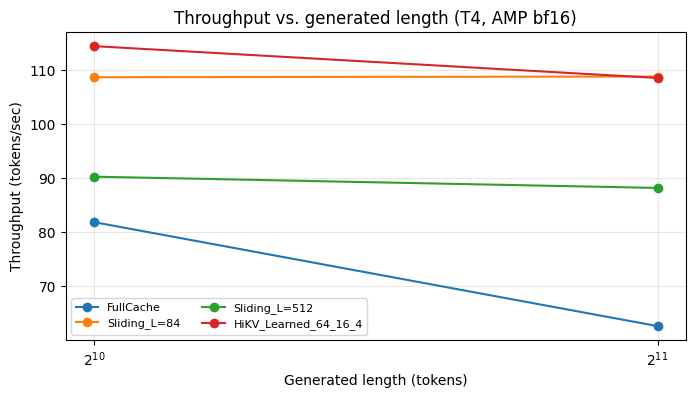

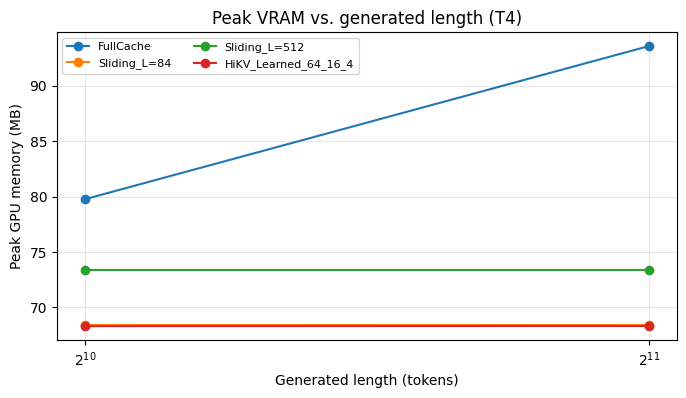


=== 300-char decoded samples (same temperature/top_p) ===

--- FullCache ---
u T. wr␤LP eito,rl dgEwat:rhd  tOr y eesehrlne hrhnh l Du.E!oynle v,dve e C␤t re␤aIe i pmwOt  ati h␤see␤dI woRd m o es␤y rbptI h seho,o  !a,omemmw mf␤mh:hofgrat as ivo acd cMlithsrny i troms noynDkl␤aanendn :o we␤VnRotee, p glettfeil cetnoThl ptOa ry n: iyn␤YsrnRhM hs shed'hrndIeathklm m␤a Mreeaoaei

--- Sliding_L=84 ---
seneooeae␤dih wrs SS ,i ou?outdis vawe␤sofrt␤rarg e pDreavhhee␤ d f.I TEehhyenhetkh 'hdarIhgm,y ntsuhl  Reuua␤ol rtio oeetls.␤r itrnyttghIoh␤ImeLelbug I he eason hordosrywlmMtl s dmhsTo i ouneoLlbLweegw coRe  A,a'sug ofEt anIbethEeeRdwsnttovheIwtsa lomer: e  IsivikeeId dowkt:e pfawivb ad f iht he mi

--- Sliding_L=512 ---
iortekcauW g  s agrirrwa onohu l s pew Sfn ustatgoIefelEdt aleoaRge hIs␤mctones␤imnirE rcoL␤ros d t at e uitgtoo g eChsc␤aiIi S.n  ynl t ueit?al  t otodEne na:gMem␤fee␤EPoTsecs scc rhusac tEKueaofooen␤!aithlw emaveiegamiE Tameal␤c rhErbowgemoa r o,ttclhle w ietlpry eot ecT s

In [14]:
#@title 🧪 Scaling: FullCache vs Sliding vs Learned-HiKV; plots + samples
import pandas as pd
import matplotlib.pyplot as plt

# Build policies (note: we want per-layer independent states)
full = FullCache()
slide84 = SlidingWindow(L=84)
slide512 = SlidingWindow(L=512)
# Learned HiKV shares pooler across layers (via new_empty_like makes layer-local state)
hikv_learned = HiKV_Learned(W0=64, W1=16, W2=4, embed_dim=model.embed_size, pooler=model.hikv_pooler)

policies = {
    "FullCache": full,
    "Sliding_L=84": slide84,
    "Sliding_L=512": slide512,
    "HiKV_Learned_64_16_4": hikv_learned,
}

lengths = [1024, 2048]
TEMPERATURE = 1.0
TOP_P = 0.9
DTYPE = 'bf16'
start_char = '\n' if '\n' in stoi else random.choice(vocab)
start_tok = torch.tensor([[stoi[start_char]]], device=device)

rows = []
samples_once = {}

for L in lengths:
    for name, pol in policies.items():
        res = stream_benchmark_t4(model, pol, start_tok, steps=L, temperature=TEMPERATURE, top_p=TOP_P, dtype=DTYPE)
        rows.append({"len": L, "policy": name,
                     "tokens_sec": res["tokens_sec"],
                     "latency_ms": res["latency_ms"],
                     "peak_mem_mb": res["peak_mem_mb"]})
        if name not in samples_once:
            samples_once[name] = res
        print(f"{L:6d} | {name:18s} | {res['tokens_sec']:.1f} tok/s | {res['latency_ms']:.2f} ms | {res['peak_mem_mb']:.1f} MB")

df = pd.DataFrame(rows)
df.to_csv("t4_learned_hikv_alibi_lora_bench.csv", index=False)
print("\nSaved: t4_learned_hikv_alibi_lora_bench.csv")

# plots
plt.figure(figsize=(8,4))
for name in policies.keys():
    sub = df[df.policy==name]
    plt.plot(sub["len"], sub["tokens_sec"], marker='o', label=name)
plt.xscale('log', base=2)
plt.xlabel("Generated length (tokens)"); plt.ylabel("Throughput (tokens/sec)")
plt.title("Throughput vs. generated length (T4, AMP bf16)")
plt.legend(ncol=2, fontsize=8); plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(8,4))
for name in policies.keys():
    sub = df[df.policy==name]
    plt.plot(sub["len"], sub["peak_mem_mb"], marker='o', label=name)
plt.xscale('log', base=2)
plt.xlabel("Generated length (tokens)"); plt.ylabel("Peak GPU memory (MB)")
plt.title("Peak VRAM vs. generated length (T4)")
plt.legend(ncol=2, fontsize=8); plt.grid(True, alpha=0.3); plt.show()

# decoded sample previews
def decode_preview(ids, n_chars=300):
    s = decode(ids[:n_chars]); return s.replace("\r","␍").replace("\n","␤")

print("\n=== 300-char decoded samples (same temperature/top_p) ===")
for name, res in samples_once.items():
    print(f"\n--- {name} ---")
    print(decode_preview(res["tokens"], 300))